In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("Admission_predict.csv")

In [3]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4   SOP                400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.3 KB


In [5]:
df.shape

(400, 9)

In [6]:
df.duplicated().sum()

0

In [7]:
df.drop(columns = "Serial No." , inplace = True)

In [8]:
df

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...
395,324,110,3,3.5,3.5,9.04,1,0.82
396,325,107,3,3.0,3.5,9.11,1,0.84
397,330,116,4,5.0,4.5,9.45,1,0.91
398,312,103,3,3.5,4.0,8.78,0,0.67


In [9]:
x = df.iloc[:,0:-1]
y = df.iloc[:,-1]

In [10]:
from sklearn.model_selection import train_test_split
x_train , x_test, y_train ,y_test = train_test_split(x,y , test_size = 0.2 , random_state = 42)

In [11]:
from sklearn.preprocessing import MinMaxScaler

In [12]:
scl = MinMaxScaler()
x_train_scaled = scl.fit_transform(x_train)
x_test_scaled = scl.transform(x_test)

In [13]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [28]:
model = Sequential()
model.add(Dense(7 , activation = "relu" ,input_dim = 7))
model.add(Dense(7 , activation = "relu"))
model.add(Dense(1,activation = "linear"))

In [29]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 7)                 56        
                                                                 
 dense_3 (Dense)             (None, 7)                 56        
                                                                 
 dense_4 (Dense)             (None, 1)                 8         
                                                                 
Total params: 120 (480.00 Byte)
Trainable params: 120 (480.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [30]:
model.compile(loss = "mean_squared_error" , optimizer = "adam")

In [31]:
history = model.fit(x_train_scaled , y_train , epochs = 100 , validation_split = 0.1)

Epoch 1/100
9/9 [==============================] - 1s 15ms/step - loss: 0.7993 - val_loss: 0.8531
Epoch 2/100
9/9 [==============================] - 0s 4ms/step - loss: 0.7029 - val_loss: 0.7401
Epoch 3/100
9/9 [==============================] - 0s 4ms/step - loss: 0.6072 - val_loss: 0.6299
Epoch 4/100
9/9 [==============================] - 0s 4ms/step - loss: 0.5054 - val_loss: 0.5094
Epoch 5/100
9/9 [==============================] - 0s 4ms/step - loss: 0.3938 - val_loss: 0.3783
Epoch 6/100
9/9 [==============================] - 0s 4ms/step - loss: 0.2812 - val_loss: 0.2609
Epoch 7/100
9/9 [==============================] - 0s 5ms/step - loss: 0.1887 - val_loss: 0.1649
Epoch 8/100
9/9 [==============================] - 0s 4ms/step - loss: 0.1161 - val_loss: 0.0938
Epoch 9/100
9/9 [==============================] - 0s 4ms/step - loss: 0.0649 - val_loss: 0.0453
Epoch 10/100
9/9 [==============================] - 0s 4ms/step - loss: 0.0337 - val_loss: 0.0216
Epoch 11/100
9/9 [==========

In [32]:
y_pred = model.predict(x_test_scaled)

3/3 [==============================] - 0s 1ms/step


In [33]:
from sklearn.metrics import r2_score
r2_score(y_test , y_pred)

0.8105366810563465

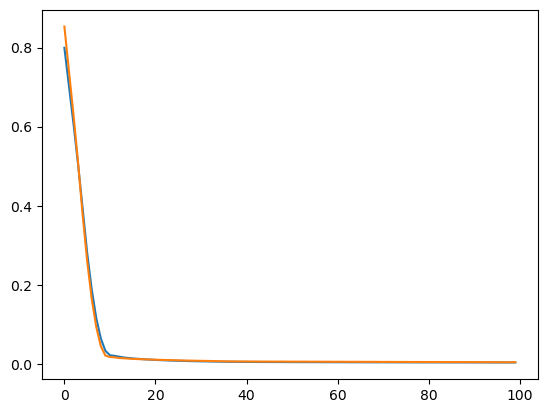

In [34]:
import matplotlib.pyplot as plt
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
